# Loading Data and Preprocessing

In [3]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [4]:

data_path = '/content/drive/MyDrive/ProjectData/HRAST.csv'


In [5]:
import pandas as pd

df = pd.read_csv(data_path)
print(df.head())


   id                                             review Unnamed: 2  positive  \
0   1                            1 elevator not working.        NaN         0   
1   2     1 euros to park per day on their own premises.        NaN         0   
2   3                          1 hour queue to check-in.        NaN         0   
3   4  1 min walk to metro entrance and also few min ...        NaN         1   
4   5  1 minute walk from the main metro & train stat...        NaN         1   

   negative  neutral  Clean  Comfort  Facilities/Amenities  Location  ...  \
0         1        0      0        0                     0         0  ...   
1         0        1      0        0                     0         0  ...   
2         1        0      0        0                     0         0  ...   
3         0        0      0        0                     0         1  ...   
4         0        0      0        0                     0         1  ...   

   Bar  Bed  Parking  Noise  Reception-checkin  Li

In [6]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23113 entries, 0 to 23112
Data columns (total 28 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   id                        23113 non-null  int64 
 1   review                    23113 non-null  object
 2   Unnamed: 2                79 non-null     object
 3   positive                  23113 non-null  int64 
 4   negative                  23113 non-null  int64 
 5   neutral                   23113 non-null  int64 
 6   Clean                     23113 non-null  int64 
 7   Comfort                   23113 non-null  int64 
 8   Facilities/Amenities      23113 non-null  int64 
 9   Location                  23113 non-null  int64 
 10  Restaurant (dinner)       23113 non-null  int64 
 11  Staff                     23113 non-null  int64 
 12  View (Balcony)            23113 non-null  int64 
 13  Breakfast                 23113 non-null  int64 
 14  Room                  

In [7]:
df.describe()

,id,positive,negative,neutral,Clean,Comfort,Facilities/Amenities,Location,Restaurant (dinner),Staff,...,Bar,Bed,Parking,Noise,Reception-checkin,Lift,Value for money,Wi-Fi,Generic,Aspect
count,23113.000000,23113.000000,23113.000000,23113.000000,23113.000000,23113.000000,23113.000000,23113.000000,23113.000000,23113.000000,...,23113.000000,23113.000000,23113.000000,23113.000000,23113.000000,23113.00000,23113.000000,23113.000000,23113.000000,23113.000000
mean,11557.000000,0.511357,0.454463,0.034353,0.126639,0.110847,0.126466,0.204603,0.012980,0.164583,...,0.013932,0.064033,0.023407,0.069398,0.041232,0.01259,0.038593,0.011595,0.085363,0.124778
std,6672.292722,0.499882,0.497933,0.182138,0.332575,0.313949,0.332381,0.403420,0.113189,0.370812,...,0.117209,0.244817,0.151195,0.254136,0.198831,0.11150,0.192627,0.107057,0.279427,0.330474
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
25%,5779.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
50%,11557.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
75%,17335.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000
max,23113.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000


In [8]:
df.drop(columns=['Unnamed: 2', 'id'], inplace=True)

In [9]:
df['Location'] = df['Location'].astype(int)

In [10]:
#Text Cleaning
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<.*?>', '', text)  # remove HTML
    text = re.sub(r'[^a-z0-9\s]', ' ', text)  # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()  # remove extra spaces
    return text

df['clean_review'] = df['review'].apply(clean_text)
df['clean_review']

,clean_review
0,1 elevator not working
1,1 euros to park per day on their own premises
2,1 hour queue to check in
3,1 min walk to metro entrance and also few min ...
4,1 minute walk from the main metro train statio...
...,...
23108,young staff that deserves success
23109,young clean a stone s throw from the city center
23110,young friendly and helpful staff
23111,young very friendly and attentive staff at rec...


In [11]:
ASPECT_COLS = [
    'Clean','Comfort','Facilities/Amenities','Location','Bar','Bed',
    'Parking','Noise','Reception-checkin','Lift','Value for money',
    'Wi-Fi','Generic'
]
NUM_ASPECTS = len(ASPECT_COLS)

In [12]:
df['sentiment_label'] = df[['negative','neutral','positive']].idxmax(axis=1)
map_sent = {'negative':0, 'neutral':1, 'positive':2}
df['sentiment'] = df['sentiment_label'].map(map_sent).astype(int)

# All data for aspect detection
all_df = df.copy()

# Count number of aspects per row
df['num_aspects'] = df[ASPECT_COLS].sum(axis=1)

# Single-aspect rows only for aspect-conditioned sentiment training
single_df = df[df['num_aspects'] == 1].copy()
single_df = single_df.reset_index(drop=True)

print("Total:", len(all_df), "Single-aspect:", len(single_df))

Total: 23113 Single-aspect: 12464


# Aspect Classification

##  TF-IDF + Logistic Regression

In [13]:
from nltk.tokenize import word_tokenize
import nltk
nltk.download('punkt_tab')

all_df['tokens'] = all_df['clean_review'].apply(word_tokenize)


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


In [14]:
all_df['tokens']

,tokens
0,"[1, elevator, not, working]"
1,"[1, euros, to, park, per, day, on, their, own,..."
2,"[1, hour, queue, to, check, in]"
3,"[1, min, walk, to, metro, entrance, and, also,..."
4,"[1, minute, walk, from, the, main, metro, trai..."
...,...
23108,"[young, staff, that, deserves, success]"
23109,"[young, clean, a, stone, s, throw, from, the, ..."
23110,"[young, friendly, and, helpful, staff]"
23111,"[young, very, friendly, and, attentive, staff,..."


In [15]:
!pip install spacy

In [16]:
import spacy

# Load the English model
nlp = spacy.load('en_core_web_sm')


In [17]:


all_df['lemmas'] = all_df['clean_review'].apply(lambda x: [token.lemma_ for token in nlp(x)])


In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.multioutput import MultiOutputClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report



# Aspect Extraction (baseline multi-label) ---
X = all_df['clean_review']
y_aspect = all_df[ASPECT_COLS]

In [19]:
# First split: 70% train, 30% temp (will split temp into val/test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y_aspect, test_size=0.3, random_state=42
)


In [20]:
# Split temp into validation and test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)


In [21]:
# TF-IDF Transformation

tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf = tfidf.transform(X_val)
X_test_tfidf = tfidf.transform(X_test)


In [22]:
# Multi-label Logistic Regression
lr = LogisticRegression(max_iter=1000)
multi_label_model = MultiOutputClassifier(lr)
multi_label_model.fit(X_train_tfidf, y_train)

MultiOutputClassifier(estimator=LogisticRegression(max_iter=1000))

In [36]:
# Predictions
y_pred_aspect = multi_label_model.predict(X_val_tfidf)
print("Aspect Extraction Baseline on Validation:")
print(classification_report(y_val, y_pred_aspect, target_names=ASPECT_COLS))


Aspect Extraction Baseline:
                      precision    recall  f1-score   support

               Clean       0.99      0.77      0.87       416
             Comfort       0.92      0.65      0.76       394
Facilities/Amenities       0.92      0.52      0.67       448
            Location       0.99      0.86      0.92       710
                 Bar       1.00      0.31      0.47        59
                 Bed       0.98      0.71      0.82       234
             Parking       1.00      0.74      0.85        78
               Noise       0.96      0.67      0.79       244
   Reception-checkin       0.83      0.38      0.52       132
                Lift       1.00      0.34      0.51        47
     Value for money       0.85      0.41      0.55       123
               Wi-Fi       1.00      0.57      0.72        46
             Generic       0.86      0.27      0.41       294

           micro avg       0.96      0.64      0.76      3225
           macro avg       0.95      0.5

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [23]:
# Predictions
y_pred_aspect = multi_label_model.predict(X_test_tfidf)
print("Aspect Extraction Baseline:")
print(classification_report(y_test, y_pred_aspect, target_names=ASPECT_COLS))


Aspect Extraction Baseline:
                      precision    recall  f1-score   support

               Clean       1.00      0.75      0.85       480
             Comfort       0.87      0.63      0.73       367
Facilities/Amenities       0.93      0.52      0.67       438
            Location       0.99      0.88      0.93       743
                 Bar       0.95      0.39      0.55        54
                 Bed       0.94      0.69      0.80       225
             Parking       1.00      0.70      0.83        88
               Noise       0.98      0.65      0.78       229
   Reception-checkin       0.78      0.39      0.52       131
                Lift       1.00      0.33      0.50        45
     Value for money       0.80      0.40      0.54       136
               Wi-Fi       1.00      0.46      0.63        46
             Generic       0.79      0.26      0.39       310

           micro avg       0.94      0.63      0.76      3292
           macro avg       0.93      0.5

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in samples with no true nor predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


## Word2Vec + Logistic Regression

In [24]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 80.3 MB/s eta 0:00:00


In [25]:
from gensim.models import Word2Vec
import numpy as np

#  1. Tokenize existing splits ---
X_train_tokens = [text.split() for text in X_train]
X_val_tokens = [text.split() for text in X_val]
X_test_tokens = [text.split() for text in X_test]

In [26]:
# 2. Train Word2Vec on training data only ---
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

In [27]:
# 3. Build average sentence vectors ---
def get_sentence_vector(tokens, model, vector_size=100):
    vecs = [model.wv[word] for word in tokens if word in model.wv]
    if len(vecs) == 0:
        return np.zeros(vector_size)
    return np.mean(vecs, axis=0)


X_train_vecs = np.array([get_sentence_vector(tokens, w2v_model) for tokens in X_train_tokens])
X_val_vecs = np.array([get_sentence_vector(tokens, w2v_model) for tokens in X_val_tokens])
X_test_vecs = np.array([get_sentence_vector(tokens, w2v_model) for tokens in X_test_tokens])

In [28]:
# 4. Logistic Regression (same as TF-IDF) ---
lr_w2v = LogisticRegression(max_iter=1000)
multi_label_w2v = MultiOutputClassifier(lr_w2v)
multi_label_w2v.fit(X_train_vecs, y_train)

MultiOutputClassifier(estimator=LogisticRegression(max_iter=1000))

In [30]:
# 5. Validation Evaluation ---
y_val_pred_w2v = multi_label_w2v.predict(X_val_vecs)
print("Aspect Extraction (Word2Vec Baseline) - Validation Set")
print(classification_report(y_val, y_val_pred_w2v, target_names=ASPECT_COLS))

Aspect Extraction (Word2Vec Baseline) - Validation Set
                      precision    recall  f1-score   support

               Clean       0.89      0.39      0.55       416
             Comfort       0.82      0.52      0.64       394
Facilities/Amenities       0.81      0.34      0.48       448
            Location       0.94      0.82      0.88       710
                 Bar       1.00      0.03      0.07        59
                 Bed       0.93      0.52      0.67       234
             Parking       0.98      0.55      0.70        78
               Noise       0.85      0.54      0.66       244
   Reception-checkin       0.76      0.28      0.41       132
                Lift       0.00      0.00      0.00        47
     Value for money       0.78      0.28      0.42       123
               Wi-Fi       0.67      0.04      0.08        46
             Generic       0.67      0.12      0.21       294

           micro avg       0.88      0.47      0.61      3225
           ma

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [42]:
# 5. Test Evaluation ---
y_test_pred_w2v = multi_label_w2v.predict(X_test_vecs)
print("Aspect Extraction (Word2Vec Baseline) - Test Set")
print(classification_report(y_test, y_test_pred_w2v, target_names=ASPECT_COLS))

Aspect Extraction (Word2Vec Baseline) - Test Set
                      precision    recall  f1-score   support

               Clean       0.91      0.38      0.53       480
             Comfort       0.82      0.49      0.62       367
Facilities/Amenities       0.79      0.33      0.46       438
            Location       0.95      0.85      0.90       743
                 Bar       1.00      0.06      0.11        54
                 Bed       0.88      0.51      0.65       225
             Parking       0.97      0.43      0.60        88
               Noise       0.87      0.42      0.57       229
   Reception-checkin       0.81      0.30      0.44       131
                Lift       0.00      0.00      0.00        45
     Value for money       0.74      0.21      0.33       136
               Wi-Fi       1.00      0.04      0.08        46
             Generic       0.71      0.15      0.24       310

           micro avg       0.89      0.46      0.60      3292
           macro av

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in samples with no predicted labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in samples with no true labels. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

In [43]:
from sklearn.metrics import f1_score
import matplotlib.pyplot as plt

# --- Calculate F1 per aspect for TF-IDF ---
f1_tfidf = []
for i, aspect in enumerate(ASPECT_COLS):
    f1 = f1_score(y_val.iloc[:, i], y_pred_aspect[:, i], average='binary')
    f1_tfidf.append(f1)

# --- Calculate F1 per aspect for Word2Vec ---
f1_w2v = []
for i, aspect in enumerate(ASPECT_COLS):
    f1 = f1_score(y_val.iloc[:, i], y_val_pred_w2v[:, i], average='binary')
    f1_w2v.append(f1)

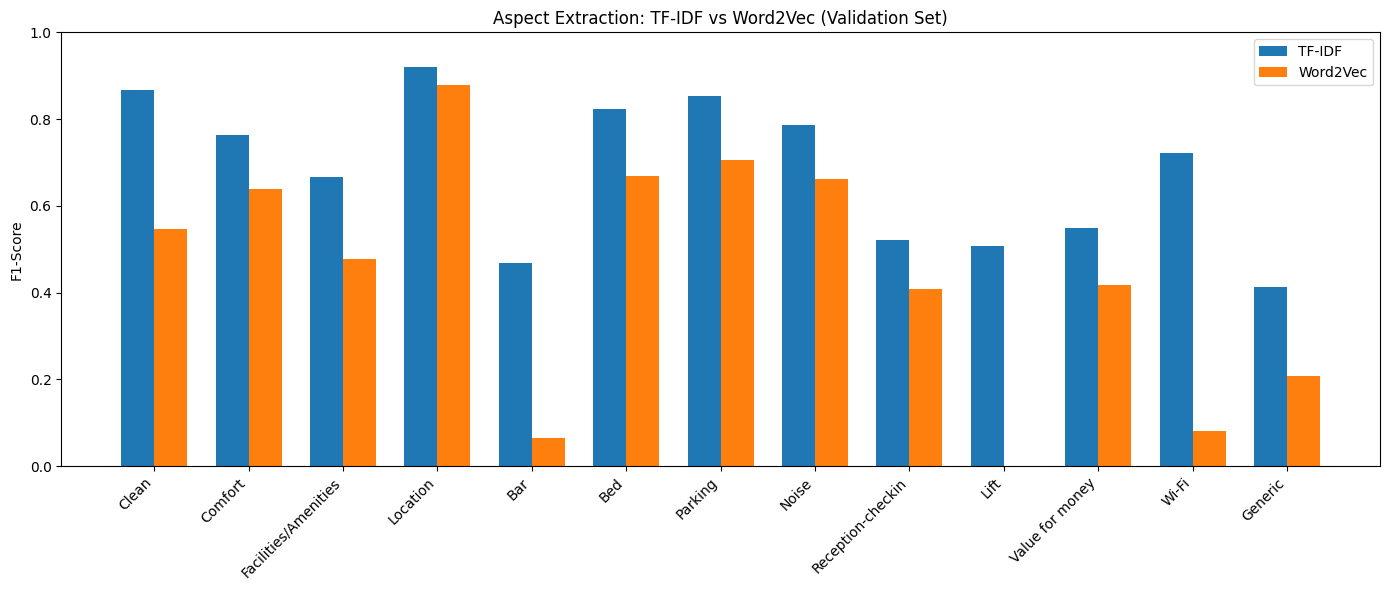

In [44]:
x = np.arange(len(ASPECT_COLS))  # label locations
width = 0.35  # width of bars

fig, ax = plt.subplots(figsize=(14,6))
rects1 = ax.bar(x - width/2, f1_tfidf, width, label='TF-IDF')
rects2 = ax.bar(x + width/2, f1_w2v, width, label='Word2Vec')

# Labels and title
ax.set_ylabel('F1-Score')
ax.set_title('Aspect Extraction: TF-IDF vs Word2Vec (Validation Set)')
ax.set_xticks(x)
ax.set_xticklabels(ASPECT_COLS, rotation=45, ha='right')
ax.legend()
plt.ylim(0, 1)  # F1-score ranges from 0 to 1
plt.tight_layout()
plt.show()


In [45]:
# Average F1 for TF-IDF
avg_f1_tfidf = np.mean(f1_tfidf)

# Average F1 for Word2Vec
avg_f1_w2v = np.mean(f1_w2v)

print("Average F1-Score Across All Aspects:")
print(f"TF-IDF: {avg_f1_tfidf:.3f}")
print(f"Word2Vec: {avg_f1_w2v:.3f}")


Average F1-Score Across All Aspects:
TF-IDF: 0.682
Word2Vec: 0.443


In [46]:

summary_df = pd.DataFrame({
    'Representation': ['TF-IDF', 'Word2Vec'],
    'Average F1-Score': [avg_f1_tfidf, avg_f1_w2v]
})

print(summary_df)


  Representation  Average F1-Score
0         TF-IDF          0.681774
1       Word2Vec          0.442740


#  Aspect-level Sentiment Classification

##  TF-IDF + Logistic Regression

In [47]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, f1_score
import numpy as np

# --- Prepare data ---
X = single_df['clean_review']  # replace with your text column name
y = single_df['sentiment']    # replace with your sentiment column name (0,1,2)

# Split into train / val / test (e.g., 70/15/15)
X_trainval, X_test, y_trainval, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_trainval, y_trainval, test_size=0.176, random_state=42, stratify=y_trainval)
# 0.176 because 0.85*0.176 ≈ 0.15 → final split ≈ 70/15/15

In [48]:
# --- TF-IDF + Logistic Regression ---
tfidf_vect = TfidfVectorizer(max_features=5000, ngram_range=(1,2))
X_train_tfidf = tfidf_vect.fit_transform(X_train)
X_val_tfidf = tfidf_vect.transform(X_val)
X_test_tfidf = tfidf_vect.transform(X_test)

clf_tfidf = LogisticRegression(max_iter=1000)
clf_tfidf.fit(X_train_tfidf, y_train)

# Predictions
val_preds_tfidf = clf_tfidf.predict(X_val_tfidf)
test_preds_tfidf = clf_tfidf.predict(X_test_tfidf)

# Metrics
print("=== TF-IDF + Logistic Regression ===")
print("Validation F1-macro:", f1_score(y_val, val_preds_tfidf, average='macro'))
print("Test F1-macro:", f1_score(y_test, test_preds_tfidf, average='macro'))
print("\nTest Classification Report:")
print(classification_report(y_test, test_preds_tfidf, zero_division=0))

=== TF-IDF + Logistic Regression ===
Validation F1-macro: 0.6414262437724431
Test F1-macro: 0.612512863262542

Test Classification Report:
              precision    recall  f1-score   support

           0       0.87      0.96      0.91       920
           1       0.00      0.00      0.00        62
           2       0.95      0.91      0.93       888

    accuracy                           0.90      1870
   macro avg       0.60      0.62      0.61      1870
weighted avg       0.88      0.90      0.89      1870



##  Word2Vec + Logistic Regression

In [49]:
from gensim.models import Word2Vec
import numpy as np

#  1. Tokenize existing splits ---
X_train_tokens = [text.split() for text in X_train]
X_val_tokens = [text.split() for text in X_val]
X_test_tokens = [text.split() for text in X_test]

In [50]:
# 2. Train Word2Vec on training data only ---
w2v_model = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1
)

In [51]:
# 3. Build average sentence vectors ---
def get_sentence_vector(tokens, model, vector_size=100):
    vecs = [model.wv[word] for word in tokens if word in model.wv]
    if len(vecs) == 0:
        return np.zeros(vector_size)
    return np.mean(vecs, axis=0)


X_train_vecs = np.array([get_sentence_vector(tokens, w2v_model) for tokens in X_train_tokens])
X_val_vecs = np.array([get_sentence_vector(tokens, w2v_model) for tokens in X_val_tokens])
X_test_vecs = np.array([get_sentence_vector(tokens, w2v_model) for tokens in X_test_tokens])

In [52]:
# Fit Logistic Regression
clf_w2v = LogisticRegression(max_iter=1000)
clf_w2v.fit(X_train_vecs, y_train)

LogisticRegression(max_iter=1000)

In [53]:
val_preds_w2v = clf_w2v.predict(X_val_vecs)
test_preds_w2v = clf_w2v.predict(X_test_vecs)

In [54]:

# Metrics
print("=== Word2Vec + Logistic Regression ===")
print("Validation F1-macro:", f1_score(y_val, val_preds_w2v, average='macro'))
print("Test F1-macro:", f1_score(y_test, test_preds_w2v, average='macro'))
print("\nTest Classification Report:")
print(classification_report(y_test, test_preds_w2v, zero_division=0))


=== Word2Vec + Logistic Regression ===
Validation F1-macro: 0.5858977192302771
Test F1-macro: 0.578681431690768

Test Classification Report:
              precision    recall  f1-score   support

           0       0.81      0.93      0.87       920
           1       0.00      0.00      0.00        62
           2       0.90      0.84      0.87       888

    accuracy                           0.85      1870
   macro avg       0.57      0.59      0.58      1870
weighted avg       0.83      0.85      0.84      1870

